# Trabalho 6

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Image
from matplotlib.animation import FuncAnimation

# local imports
sys.path.append(os.path.abspath(r"../util/"))


from geometry import Pose, Angle
from robot import Robot
from maps import LandmarkMap, Landmark
from control import VelocityControl, generateConstantVelocityTrajectory
from ekf import EKFSlamKnownCorrespondences
from camera import Camera, DetectedFeature
from motion_models import CircularMotion

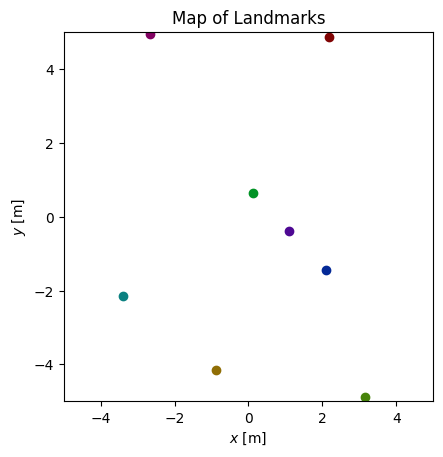

In [3]:
# create map
n_landmarks = 8

x_lims = (-5, 5)
y_lims = (-5, 5)

landmarks = []
for signature in range(n_landmarks):
    #sample coordinates in roi
    x = np.random.uniform(x_lims[0], x_lims[1])
    y = np.random.uniform(y_lims[0], y_lims[1])
    phi = Angle(np.random.uniform(0, 2 * np.pi))
    #create landmark
    landmarks.append(Landmark(Pose(x, y, phi), signature))

env = LandmarkMap(landmarks, x_lims=x_lims, y_lims=y_lims)

#plot map
f, ax = plt.subplots()

ax.set_title("Map of Landmarks")
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]")
ax.set_aspect('equal', adjustable='box')

env.draw(ax)

In [4]:
#set initial position
x0 = Pose(0, 0, Angle.from_deg(10.))

#set dt for simulation
dt = 0.05

In [5]:
fov = Angle.from_deg(60) #[°]
sensor_range = 5 #[m]

#define robot's sensor
camera = Camera(Pose(0.5, 0, Angle(0)), field_of_veiw=fov, sensor_range=sensor_range, robot_pose=x0)

In [6]:
#define the robot
robot = Robot(
    x0, 
    sensors = [
        camera
    ],
)

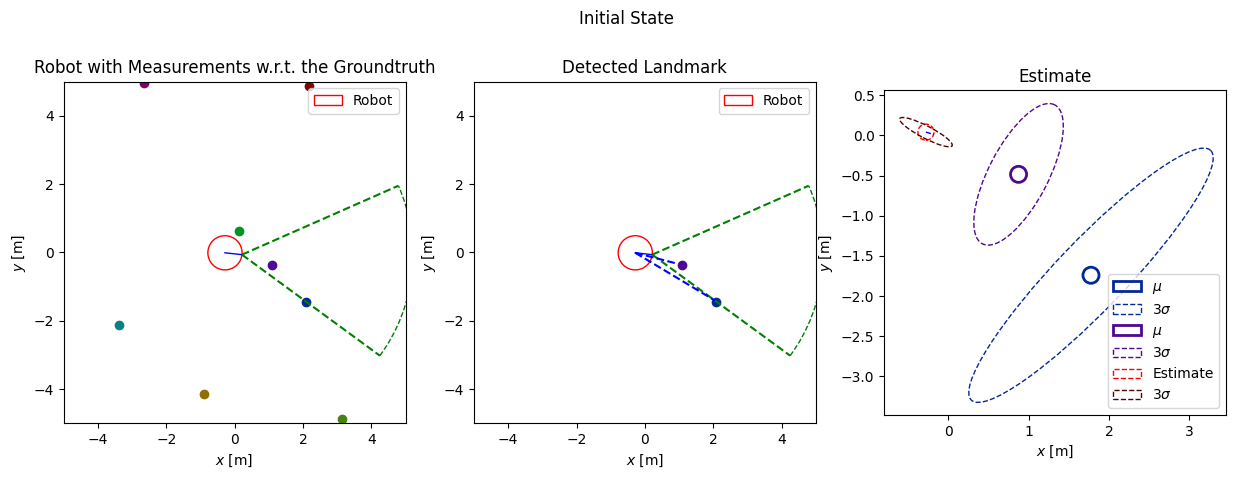

In [13]:
ekf = EKFSlamKnownCorrespondences()

u = VelocityControl(1,1,1)
_ = robot.applyControl(u)
robot.measure(env, detection_noise=True)

#plot initial state, with first measurement
f = plt.figure(figsize=(15, 5))
f.suptitle("Initial State")

ax1 = plt.subplot(1,3, 1)
ax1.set_title("Robot with Measurements w.r.t. the Groundtruth")
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m]")
env.draw(ax1)
robot.draw(ax1, r = 0.5)

ax2 = plt.subplot(1,3, 2)
ax2.set_title("Detected Landmark")
ax2.set_xlabel("$x$ [m]")
ax2.set_ylabel("$y$ [m]")
env.draw(ax2, correspondences=robot.sensors[0].reading["correspondences"])
robot.draw(ax2, r = 0.5, draw_sensor_readings=True)

ax3 = plt.subplot(1,3, 3)
ax3.set_title("Estimate")
ax3.set_xlabel("$x$ [m]")
ax3.set_ylabel("$y$ [m]")
ekf.update(CircularMotion(x0,robot.pos,1),robot.sensors[0].reading["features"])
ekf.draw(ax3, env.colors)

In [8]:
print(robot.sensors[0].reading)

{'features': [DetectedFeature(4.47, Angle(4.37°), 7)], 'correspondences': [7]}
